In [1]:
import csv
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Skrypt pozwoli na stworzenie modelu i wytrenowanie go. Po zakończonym trenowaniu należy wyciągnąć wartości weight i bias z warstw liniowych i przekopiować je do swojego modelu napisanego w Numpy (przekopiować wartości). Proszę o zapisanie wykresów trenowania i pokazanie ich na następnych zajęciach (może być w formie surowej po prostu screenów).

In [2]:
# Stwórz odpowiedni model w miejsce kropek: model z jedną warstwą ukrytą z 5 neuronami, model z jedną warstwa ukrytą z 10 neuronami, model z dwiema warstwami ukrytymi z 5 neuronami.
# Do stworzenia modelu wykorzystaj: nn.Sequential, nn.Linear, nn.Sigmoid
# nn.Linear - https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
# nn.Sequential - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# nn.Sigmoid - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

# Trenujemy i testujemy po jednym modelu na raz. Testowanie następnego modelu wymaga włączenie wszystkich komórek jeszcze raz.

model = nn.Sequential(
    nn.Linear(in_features=1, out_features=5),
    nn.Sigmoid(),
    nn.Linear(in_features=5, out_features=1),
    nn.Sigmoid(),
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=1, bias=True)
  (3): Sigmoid()
)


In [3]:
# Ustal parametry

# Ile kroków ma zostać wykonane podczas treningu. Dlugosc treningu to int
# Długość treningu pomiędzy bazami danych może się drastycznie różnić. Trening może potrwać kilka, kilkanaście minut.
# Gpu można włączyć w ustawieniach "change runtime type" i wybrać T4 GPU - ta opcja jest bezpłatnie dostępna z limitem.
# Proponuję trenować bazę danych steps na ponad 20k, wartość warto dobrać te wartość na podstawie dopasowania na końcu na wykresie i wartości błędu.
# Jeśli model nie jest wystarczająco wytrenowany to można kontynuować trenowanie za pomocą ponownego odpalenia komórki z komentarzem # Trening
dlugosc_treningu = 100000

# Czy znormalizować dane wejsciowe i wyjsciowe. Czy znormalizowac to bool
czy_znormalizowac = 1

In [4]:
# Załaduj dane uczące. Wpisz w miejsce kropek numer bazy danych

dataset_id = 1

if dataset_id == 0:
  # Dataset 1
  data = csv.reader(open('../datasets/regression/square-simple-training.csv'))
  test_data = csv.reader(open('../datasets/regression/square-simple-test.csv'))
elif dataset_id == 1:
  # Dataset 2
  data = csv.reader(open('../datasets/regression/steps-large-training.csv'))
  test_data = csv.reader(open('../datasets/regression/steps-large-test.csv'))
else:
  assert False, f"Wybrana baza danych nie jest dostępna."

In [5]:
# Jeżeli jest dostępne GPU to wykonaj trening na GPU, jeśli nie to na CPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Trening zostanie wykonany na {device}")

Trening zostanie wykonany na cpu


In [6]:
# Przygotuj dane uczące
x_list = []
y_list = []
for i, row in enumerate(data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    x_list.append(x)
    y_list.append(y)

# Przygotuj dane testujace
test_x_list = []
test_y_list = []
for i, row in enumerate(test_data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    test_x_list.append(x)
    test_y_list.append(y)

In [7]:
# Funkcja straty
criterion = nn.MSELoss()
# Optymalizator
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
# Treninig
for i in range(dlugosc_treningu):
  x_to_plot = []
  y_to_plot = []
  y_pred_to_plot = []

  x = torch.tensor(x_list).reshape(-1,1).to(device)
  y = torch.tensor(y_list).reshape(-1,1).to(device)

  if czy_znormalizowac:
    x_min = x.min()
    x_max = x.max()
    y_min = y.min()
    y_max = y.max()

    x_normalized = (x - x_min) / (x_max - x_min)
    y_normalized = (y - y_min) / (y_max - y_min)
  else:
    x_normalized = x
    y_normalized = y

  y_pred = model(x_normalized)

  x_to_plot = x_to_plot + x.tolist()
  y_to_plot = y_to_plot + y.tolist()
  y_pred_to_plot = y_pred_to_plot + (y_pred*(y.max() - y.min()) + y.min()).tolist()

  loss = criterion(y_pred, y_normalized)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if i % 100 == 0:
    print(f"Wartość funkcja straty podczas treningu, krok: {i}, {loss.item()}")

if czy_znormalizowac:
  print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
  normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
  print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
else:
  print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

Wartość funkcja straty podczas treningu, krok: 0, 0.12470105290412903
Wartość funkcja straty podczas treningu, krok: 100, 0.0731436237692833
Wartość funkcja straty podczas treningu, krok: 200, 0.013153955340385437
Wartość funkcja straty podczas treningu, krok: 300, 0.010539849288761616
Wartość funkcja straty podczas treningu, krok: 400, 0.010437286458909512
Wartość funkcja straty podczas treningu, krok: 500, 0.010424312204122543
Wartość funkcja straty podczas treningu, krok: 600, 0.010412429459393024
Wartość funkcja straty podczas treningu, krok: 700, 0.010397931560873985
Wartość funkcja straty podczas treningu, krok: 800, 0.010379131883382797
Wartość funkcja straty podczas treningu, krok: 900, 0.010355453006923199
Wartość funkcja straty podczas treningu, krok: 1000, 0.010326978750526905
Wartość funkcja straty podczas treningu, krok: 1100, 0.010293923318386078
Wartość funkcja straty podczas treningu, krok: 1200, 0.010257347486913204
Wartość funkcja straty podczas treningu, krok: 1300, 

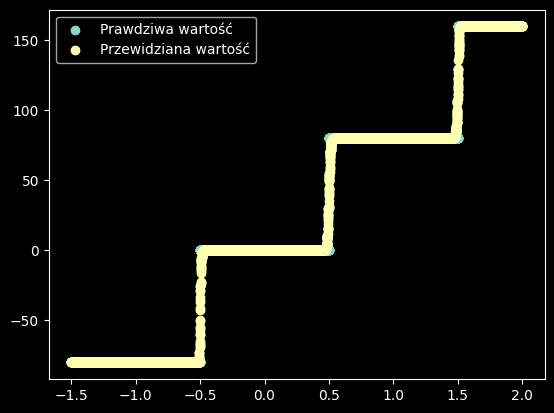

In [9]:
# Wyświetl jak wygląda predykcja modelu dla ostatniego kroku

plt.scatter(x_to_plot, y_to_plot)
plt.scatter(x_to_plot, y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [10]:
# Przetestuj model na zbiorze testowym

test_x_to_plot = []
test_y_to_plot = []
test_y_pred_to_plot = []


x = torch.tensor(test_x_list).reshape(-1,1).to(device)
y = torch.tensor(test_y_list).reshape(-1,1).to(device)

if czy_znormalizowac:
  x_normalized = (x - x_min) / (x_max - x_min)
  y_normalized = (y - y_min) / (y_max - y_min)
else:
  x_normalized = x
  y_normalized = y

y_pred = model(x_normalized)

test_x_to_plot = test_x_to_plot + x.tolist()
test_y_to_plot = test_y_to_plot + y.tolist()
test_y_pred_to_plot = test_y_pred_to_plot + (y_pred*(y_max - y_min) + y_min).tolist()

loss = criterion(y_pred, y_normalized)

if czy_znormalizowac:
  print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
  normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
  print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
else:
  print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

Znormalizowana finalna wartość funkcji straty: 0.00015055273252073675
Nieznormalizowana finalna wartość funkcji straty: 8.671836853027344


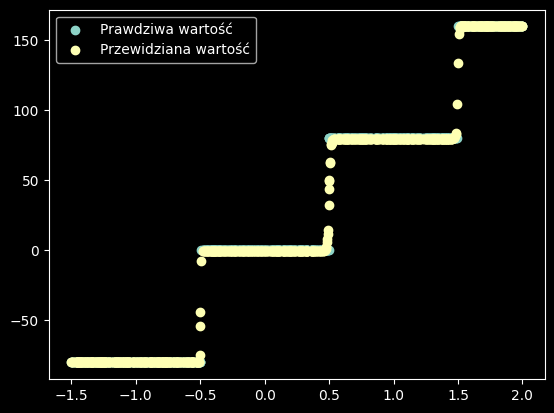

In [11]:
# Wyświetl prawdziwą wartość funkcji i przewidzianą wartość nieznormalizowaną

plt.scatter(test_x_to_plot, test_y_to_plot)
plt.scatter(test_x_to_plot, test_y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [12]:
# Funkcja do wyciągania wag z warstw liniowych

def get_weights_and_bias(linear_layer):
    print(f"Waga: {linear_layer.weight.data.cpu().numpy()}")
    print(f"Bias: {linear_layer.bias.data}")

# Przykład wyciągniecia wag z pierwszej warstwy liniowej
layer = model[0]
get_weights_and_bias(layer)

Waga: [[-484.84277 ]
 [   4.643681]
 [   6.528776]
 [-569.94556 ]
 [-723.3776  ]]
Bias: tensor([418.6030, -22.2236,  14.7672, 325.4636, 201.0621])


In [13]:
# Wyciągnij wagi ze wszystkich warstw liniowych i wklej je do swojego modelu w numpy.
# Uważaj na orientację wagi, być może trzeba będzie ją transponować!!! Pytorch może inaczej wymnażać X i weights niż wasz kod.

# Tu zrób kod
layer = model[2]
get_weights_and_bias(layer)

Waga: [[ -18.584955     4.1744523    9.309974    -1.3874879 -228.49208  ]]
Bias: tensor([9.9651])
